In [24]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

In [25]:
dane00=pd.read_csv('pokemon_data.csv')
#..procent męskich i żenskich pokemonow według typu pierwszego 
daneG_typ1=dane00.groupby('type1')
#..obliczanie średniej i dodanie kolumny z wartością przeciwną dla %male
srednie_typ_plec=daneG_typ1[['percent_male','percent_female']].mean().reset_index()
srednie_typ_plec.columns=['Typ','%male','%female']
srednie_typ_plec['%male neg']=srednie_typ_plec['%male']*(-1)

#..sortowanie wg %female - ascending=True, bo barh rysuje pierwszy wiersz na dole wykresu, czyli tam musi być najmniejszy procent
srednie_typ_plec = srednie_typ_plec.sort_values('%female', ascending=True)

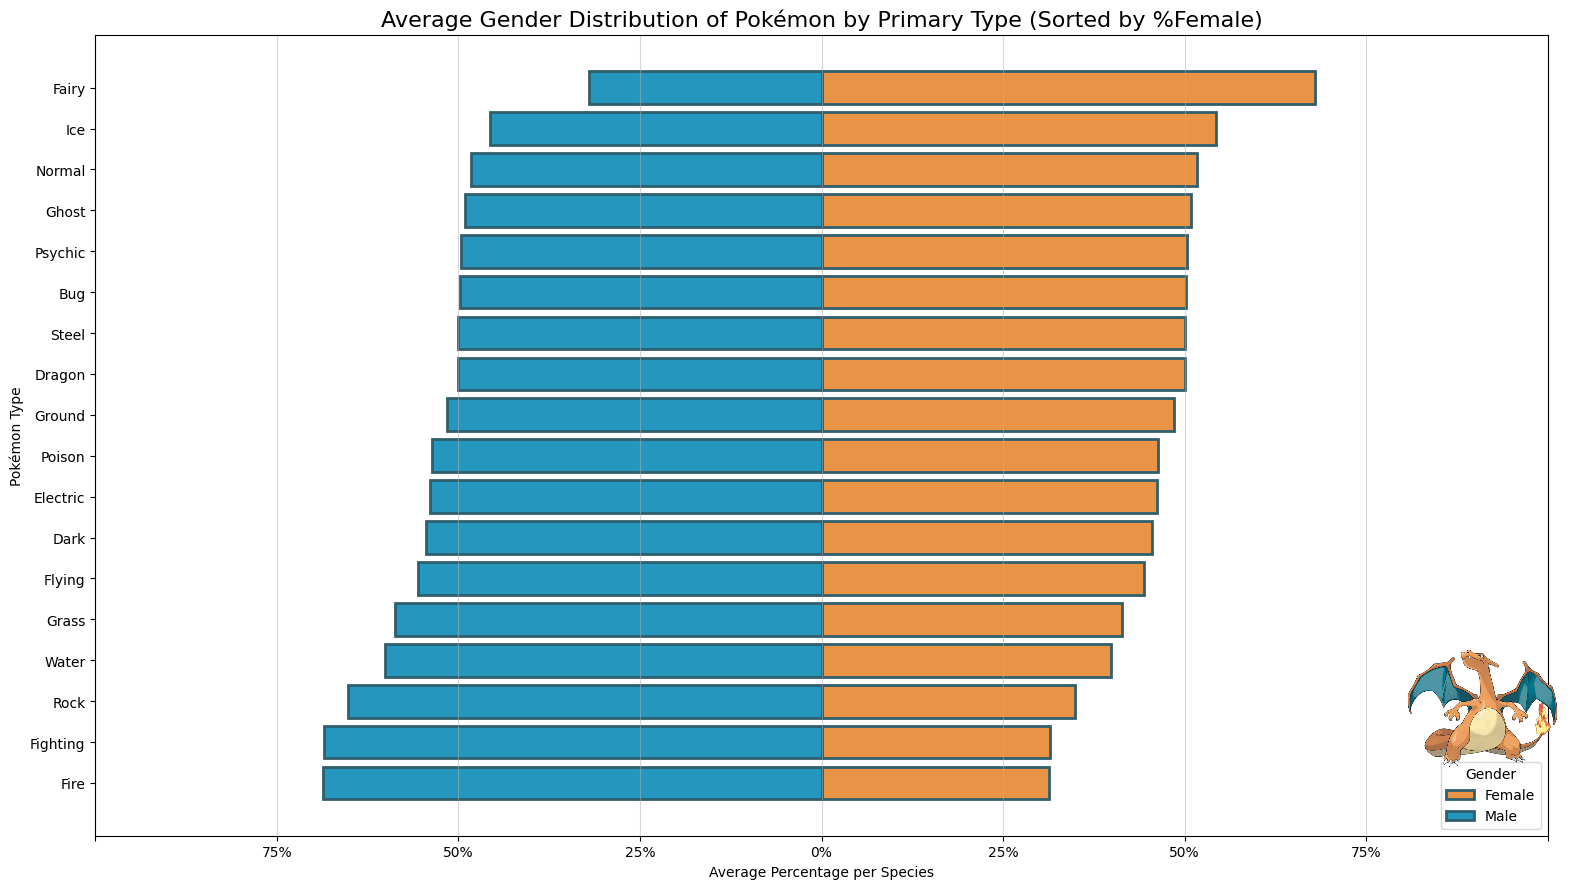

In [27]:
fig, ax = plt.subplots(figsize=(16,9))

plt.barh(srednie_typ_plec['Typ'],srednie_typ_plec['%female'],color='#e99346',edgecolor='#2f5f6d',linewidth=2,label='Female')
plt.barh(srednie_typ_plec['Typ'],srednie_typ_plec['%male neg'],color='#2596be',edgecolor='#2f5f6d',linewidth=2,label='Male')

plt.grid(axis='x', alpha=0.5)
znaczniki=[-100,-75,-50,-25,0,25,50,75,100] #znaczniki na osi x
nowe_ticks= [f'{abs(x):.0f}%' if abs(x)!=100 else "" for x in znaczniki]
plt.xticks(znaczniki,nowe_ticks)

#..dodawanie pokemona do wykresu - Charizard
img = plt.imread('images/images/6.png')
imagebox = OffsetImage(img, zoom=0.25) 
ab = AnnotationBbox(imagebox, xy=(91, 1.82), frameon=False, zorder=10)
ax.add_artist(ab)

#..opis wykresu, osi, legenda
plt.title('Average Gender Distribution of Pokémon by Primary Type (Sorted by %Female)', fontsize=16)
plt.xlabel('Average Percentage per Species')
plt.ylabel('Pokémon Type')
plt.legend(title='Gender', loc='lower right')

plt.tight_layout()
plt.savefig('gender.png')
plt.show()